In [1]:
# 01.09.2026 - domkniecie punktu otwartego z 31.08 (patrz 20260831/
# 20260831.txt, sekcja "Otwarte punkty"): ROZBICIE LANCUCHA POST-TRIAL NA
# POSZCZEGOLNE ERY + JAWNY POWOD BRAKU WYNIKU.
#
# Problem. Funkcje penalized_chain / penalized_chain_fixed z 20260831b.ipynb
# zwracaly tylko finalna sigma, wiec nie wiadomo bylo, czy wynik danej
# stacji (np. hrms) bierze sie z JEDNEJ dominujacej ery, czy jest rozlozony
# rownomiernie po wszystkich czterech. To jest pierwsze pytanie, ktore
# zada recenzent: "ktore minimum robi wam ten wynik?". Drugi brak: stacje
# bez wyniku mialy w tabeli NaN bez wyjasnienia, choc powody sa co najmniej
# trzy i zupelnie rozne (brak danych CR w tej epoce / brak minimum w oknie /
# minimum za daleko od wspolnego punktu sieci).
#
# WEJSCIE - tylko juz policzone pliki, zero skanow:
#   results/section4_network_minima.csv                       (31.08, Watek 1)
#   results/finetune_{stacja}_P3350_d5_dt15_fullhistory.csv    (26.08)
#   results/section4_penalized_significance.csv                (31.08, Krok 5)
#   results/section4_penalized_significance_stale_punkty.csv   (31.08, Krok 7)
#
# METODA: doslowne powtorzenie obu lancuchow z 20260831b.ipynb (te same
# wzory, te same stale), ale z zapisem KAZDEGO czynnika osobno:
#   czynnik_i = PPDF_i * n_i,   n_i = (granica - poprzedni_punkt) / 5 dni
#   iloczyn   = product(czynnik_i),   sigma = norm.isf(iloczyn)
# Ostatnia komorka sprawdza, czy przeliczone iloczyny zgadzaja sie z
# zapisanymi 31.08 - jesli nie, to znaczy, ze to rozbicie NIE opisuje tego
# lancucha, ktory dal opublikowane w dzienniku liczby.
import numpy as np
import pandas as pd
from scipy.stats import norm

RESULTS_DIR = "../results"

D_DAYS = 5
BURNING_START = pd.Timestamp("2005-03-30")  # pierwszy rekord Augera (sekcja 3 artykulu)
TOLERANCJA_DNI = 30                          # jak 20260831b.ipynb, Krok 7
ERY_ARTYKULU = [1968, 1978, 1988, 1999]      # cztery ery sprzed burning sample
ERY_WSZYSTKIE = [1968, 1978, 1988, 1999, 2008]

network_minima = pd.read_csv(
    f"{RESULTS_DIR}/section4_network_minima.csv",
    parse_dates=["station_t0_min", "station_t0_max", "t0_h5", "t0_h6"])

STATIONS = sorted(network_minima["station"].unique())
station_ranges = network_minima.groupby("station").agg(
    data_start=("station_t0_min", "first"), data_end=("station_t0_max", "first"))

era_centers = (network_minima[network_minima["matched_h5"]]
               .groupby("era")["t0_h5"].median())

finetune = {}
for st in STATIONS:
    finetune[st] = pd.read_csv(
        f"{RESULTS_DIR}/finetune_{st}_P3350_d5_dt15_fullhistory.csv",
        parse_dates=["t0"]).sort_values("t0").reset_index(drop=True)

print(f"Stacje: {len(STATIONS)}")
print("Centra er (mediana po sieci, definicja z Watku 1):")
print(era_centers)


Stacje: 20
Centra er (mediana po sieci, definicja z Watku 1):
era
1968   1968-06-30 00:00:00
1972   1972-12-26 18:00:00
1978   1978-05-23 12:00:00
1988   1988-12-08 21:00:00
1999   1999-03-22 09:00:00
2008   2008-10-20 09:00:00
2014   2014-05-03 00:00:00
Name: t0_h5, dtype: datetime64[us]


In [2]:
# Funkcja pomocnicza - identyczna jak 20260831b.ipynb, Krok 7, ale
# dodatkowo zwraca ODLEGLOSC znalezionego punktu od zadanej daty (do
# kolumny z powodem braku wyniku).
def punkt_w_dacie(df, date, tolerance_days=TOLERANCJA_DNI):
    idx = (df["t0"] - date).abs().idxmin()
    nearest = df.loc[idx]
    dist = abs((nearest["t0"] - date).days)
    if dist > tolerance_days:
        return None, dist
    return nearest, dist


# Lancuch z ZAPISEM KAZDEGO CZYNNIKA. Dwie metody, dokladnie jak 31.08:
#  - "wolna"  (Krok 4-5): punktem jest WLASNE minimum stacji znalezione
#    przez find_peaks w oknie erowym; budzet prob n_i liczony od poprzednio
#    znalezionego minimum; n_i <= 0 przerywa CALY lancuch (zwrot None).
#  - "stala"  (Krok 7): punktem jest wspolne dla sieci centrum ery (+-30
#    dni tolerancji); budzet n_i liczony od poprzedniego CENTRUM; brak
#    punktu w tolerancji pomija dana ere, ale nie przerywa lancucha.
def lancuch_wolny(era_rows, data_start, boundary):
    prev, terms = data_start, []
    for _, row in era_rows.iterrows():
        n = (boundary - prev).days / D_DAYS
        if n <= 0:
            terms.append(dict(era=int(row["era"]), status="przerwany_budzet_prob",
                              t0_uzyty=row["t0_h5"], PPDF=10 ** (-row["neglog10_PPDF_h5"]),
                              n_prob=n, czynnik=np.nan))
            return terms, False
        ppdf = 10 ** (-row["neglog10_PPDF_h5"])
        terms.append(dict(era=int(row["era"]), status="uzyty", t0_uzyty=row["t0_h5"],
                          PPDF=ppdf, n_prob=n, czynnik=ppdf * n))
        prev = row["t0_h5"]
    return terms, True


def lancuch_staly(era_list, station_df, data_start, boundary):
    prev, terms = data_start, []
    for era in era_list:
        date = era_centers[era]
        point, dist = punkt_w_dacie(station_df, date)
        if point is None:
            terms.append(dict(era=int(era), status="pominieta_brak_punktu_w_tolerancji",
                              t0_uzyty=pd.NaT, PPDF=np.nan, n_prob=np.nan, czynnik=np.nan,
                              odleglosc_dni=dist))
            continue
        n = (boundary - prev).days / D_DAYS
        if n <= 0:
            terms.append(dict(era=int(era), status="pominieta_budzet_prob",
                              t0_uzyty=point["t0"], PPDF=point["PPDF"], n_prob=n,
                              czynnik=np.nan, odleglosc_dni=dist))
            continue
        terms.append(dict(era=int(era), status="uzyty", t0_uzyty=point["t0"],
                          PPDF=point["PPDF"], n_prob=n, czynnik=point["PPDF"] * n,
                          odleglosc_dni=dist))
        prev = date
    return terms, True


print("Funkcje lancuchow gotowe (wzory przepisane 1:1 z 20260831b.ipynb).")


Funkcje lancuchow gotowe (wzory przepisane 1:1 z 20260831b.ipynb).


In [3]:
# Budowa dlugiej tabeli stacja x era x metoda x wariant, z czynnikami,
# iloczynem narastajaco i sigma narastajaco. Cztery kombinacje, te same co
# 31.08:
#   metoda: wolna / stala      (swobodny wybor punktu vs punkt sieciowy)
#   wariant: a_z_wykluczeniem  (tylko ery < 2008, granica = burning sample)
#            b_bez_wykluczenia (wszystkie ery, granica = koniec danych stacji)
wiersze = []
podsumowanie = []

for st in STATIONS:
    df_st = finetune[st]
    data_start = station_ranges.loc[st, "data_start"]
    data_end = station_ranges.loc[st, "data_end"]
    st_rows = network_minima[(network_minima["station"] == st)
                             & (network_minima["matched_h5"])].sort_values("t0_h5")

    konfiguracje = [
        ("wolna", "a_z_wykluczeniem", lambda: lancuch_wolny(st_rows[st_rows["era"] < 2008],
                                                            data_start, BURNING_START)),
        ("wolna", "b_bez_wykluczenia", lambda: lancuch_wolny(st_rows, data_start, data_end)),
        ("stala", "a_z_wykluczeniem", lambda: lancuch_staly(ERY_ARTYKULU, df_st,
                                                            data_start, BURNING_START)),
        ("stala", "b_bez_wykluczenia", lambda: lancuch_staly(ERY_WSZYSTKIE, df_st,
                                                             data_start, data_end)),
    ]

    for metoda, wariant, fn in konfiguracje:
        terms, ok = fn()
        biezacy = 1.0
        for t in terms:
            rec = dict(station=st, metoda=metoda, wariant=wariant, lancuch_kompletny=ok, **t)
            if t["status"] == "uzyty":
                biezacy *= t["czynnik"]
                rec["iloczyn_narastajaco"] = biezacy
                rec["sigma_narastajaco"] = (float(norm.isf(biezacy))
                                            if 0 < biezacy < 1 else np.nan)
                rec["wklad_neglog10"] = -np.log10(t["czynnik"])
            wiersze.append(rec)

        uzyte = [t for t in terms if t["status"] == "uzyty"]
        if ok and uzyte:
            iloczyn = float(np.prod([t["czynnik"] for t in uzyte]))
            sigma = float(norm.isf(iloczyn)) if 0 < iloczyn < 1 else np.nan
        else:
            iloczyn, sigma = np.nan, np.nan
        podsumowanie.append(dict(station=st, metoda=metoda, wariant=wariant,
                                 n_minima=len(uzyte) if ok else 0,
                                 product=iloczyn, sigma_post_trial=sigma))

per_era = pd.DataFrame(wiersze)
per_era = per_era[["station", "metoda", "wariant", "era", "status", "t0_uzyty",
                   "PPDF", "n_prob", "czynnik", "wklad_neglog10",
                   "iloczyn_narastajaco", "sigma_narastajaco",
                   "odleglosc_dni", "lancuch_kompletny"]]
per_era.to_csv(f"{RESULTS_DIR}/section4_penalized_chain_per_era.csv", index=False)
podsumowanie = pd.DataFrame(podsumowanie)
print(f"Zapisano {RESULTS_DIR}/section4_penalized_chain_per_era.csv, {len(per_era)} wierszy")
print()
print("Interpretacja kolumny wklad_neglog10: -log10(czynnik). Iloczyn calego")
print("lancucha = suma tych wkladow w skali log10, wiec kolumna mowi wprost,")
print("ILE DANEJ ERZE zawdzieczamy w finalnym wyniku. Wartosc ujemna = era")
print("POGARSZA wynik (jej PPDF nie nadraza wlasnego budzetu prob n_i).")


Zapisano ../results/section4_penalized_chain_per_era.csv, 271 wierszy

Interpretacja kolumny wklad_neglog10: -log10(czynnik). Iloczyn calego
lancucha = suma tych wkladow w skali log10, wiec kolumna mowi wprost,
ILE DANEJ ERZE zawdzieczamy w finalnym wyniku. Wartosc ujemna = era
POGARSZA wynik (jej PPDF nie nadraza wlasnego budzetu prob n_i).


In [4]:
# Kontrola zgodnosci z 31.08: przeliczone iloczyny musza sie zgadzac z
# tym, co zapisano wtedy w results/section4_penalized_significance*.csv.
# Jesli sie nie zgadzaja, cale rozbicie na ery opisuje INNY lancuch niz ten,
# ktory dal liczby w dzienniku - i to jest blad do naprawienia, a nie
# szczegol do przemilczenia.
stare_wolne = pd.read_csv(f"{RESULTS_DIR}/section4_penalized_significance.csv")
stare_stale = pd.read_csv(f"{RESULTS_DIR}/section4_penalized_significance_stale_punkty.csv")

for metoda, stare in [("wolna", stare_wolne), ("stala", stare_stale)]:
    nowe = podsumowanie[podsumowanie["metoda"] == metoda]
    porownanie = stare.merge(nowe, on=["station", "wariant"], suffixes=("_31_08", "_dzis"))
    obie = porownanie.dropna(subset=["sigma_post_trial_31_08", "sigma_post_trial_dzis"])
    if len(obie):
        roznica = (obie["sigma_post_trial_31_08"] - obie["sigma_post_trial_dzis"]).abs().max()
    else:
        roznica = np.nan
    tylko_stare = porownanie["sigma_post_trial_31_08"].notna().sum()
    tylko_nowe = porownanie["sigma_post_trial_dzis"].notna().sum()
    print(f"metoda={metoda}: porownanych wierszy {len(porownanie)}, "
          f"z wynikiem 31.08: {tylko_stare}, z wynikiem dzis: {tylko_nowe}")
    print(f"    najwieksza roznica sigma: {roznica:.2e}"
          if not np.isnan(roznica) else "    brak wspolnych wierszy do porownania")
    if not np.isnan(roznica) and roznica > 1e-6:
        print("    UWAGA: rozbieznosc powyzej tolerancji - NIE uzywac tego rozbicia")
        print("    do interpretacji, dopoki nie zostanie wyjasniona.")


metoda=wolna: porownanych wierszy 40, z wynikiem 31.08: 34, z wynikiem dzis: 34
    najwieksza roznica sigma: 1.78e-15
metoda=stala: porownanych wierszy 40, z wynikiem 31.08: 31, z wynikiem dzis: 31
    najwieksza roznica sigma: 8.88e-16


In [5]:
# Kolumna z POWODEM braku wyniku - dla kazdej pary stacja x era z listy
# er artykulu, osobno dla obu metod. Powody sa rozlaczne i uporzadkowane od
# najbardziej podstawowego (nie ma danych) do najbardziej szczegolowego
# (dane sa, punkt jest, ale za daleko od wspolnego punktu sieci).
powody = []
for st in STATIONS:
    df_st = finetune[st]
    for era in ERY_WSZYSTKIE:
        wiersz = network_minima[(network_minima["station"] == st)
                                & (network_minima["era"] == era)]
        ma_dane = bool(wiersz["has_data_in_era"].iloc[0]) if len(wiersz) else False
        ma_minimum = bool(wiersz["matched_h5"].iloc[0]) if len(wiersz) else False

        _, dist = punkt_w_dacie(df_st, era_centers[era])

        if not ma_dane:
            powod_wolna = "brak danych CR w oknie erowym (+-2 lata)"
        elif not ma_minimum:
            powod_wolna = "dane sa, ale find_peaks nie znalazl minimum (prog 5.0)"
        else:
            powod_wolna = "OK"

        if dist > TOLERANCJA_DNI:
            powod_stala = (f"najblizszy punkt {dist} dni od centrum sieci "
                           f"(> tolerancja {TOLERANCJA_DNI} dni)")
        else:
            powod_stala = "OK"

        powody.append(dict(station=st, era=era, ma_dane_w_erze=ma_dane,
                           ma_minimum_h5=ma_minimum,
                           odleglosc_do_centrum_sieci_dni=dist,
                           powod_metoda_wolna=powod_wolna,
                           powod_metoda_stala=powod_stala))

powody = pd.DataFrame(powody)
powody.to_csv(f"{RESULTS_DIR}/section4_penalized_chain_reasons.csv", index=False)
print(f"Zapisano {RESULTS_DIR}/section4_penalized_chain_reasons.csv, {len(powody)} wierszy")
print()
print("Rozklad powodow, metoda ze stalym punktem:")
print(powody["powod_metoda_stala"].str.replace(r"\d+", "N", regex=True).value_counts())
print()
print("Rozklad powodow, metoda z wolnym przeszukiwaniem:")
print(powody["powod_metoda_wolna"].value_counts())
print()
print("Stacje bez wyniku w erze 1999 (najczestszy przypadek brzegowy, 31.08):")
print(powody[(powody["era"] == 1999) & (powody["powod_metoda_stala"] != "OK")]
      [["station", "odleglosc_do_centrum_sieci_dni", "powod_metoda_stala"]].to_string(index=False))


Zapisano ../results/section4_penalized_chain_reasons.csv, 100 wierszy

Rozklad powodow, metoda ze stalym punktem:
powod_metoda_stala
OK                                                              60
najblizszy punkt N dni od centrum sieci (> tolerancja N dni)    40
Name: count, dtype: int64

Rozklad powodow, metoda z wolnym przeszukiwaniem:
powod_metoda_wolna
OK                                                        53
brak danych CR w oknie erowym (+-2 lata)                  32
dane sa, ale find_peaks nie znalazl minimum (prog 5.0)    15
Name: count, dtype: int64

Stacje bez wyniku w erze 1999 (najczestszy przypadek brzegowy, 31.08):
station  odleglosc_do_centrum_sieci_dni                                               powod_metoda_stala
   apty                             466  najblizszy punkt 466 dni od centrum sieci (> tolerancja 30 dni)
   athn                             599  najblizszy punkt 599 dni od centrum sieci (> tolerancja 30 dni)
   fsmt                             561  

Zapisano ../results/section4_chain_per_era_heatmap.png


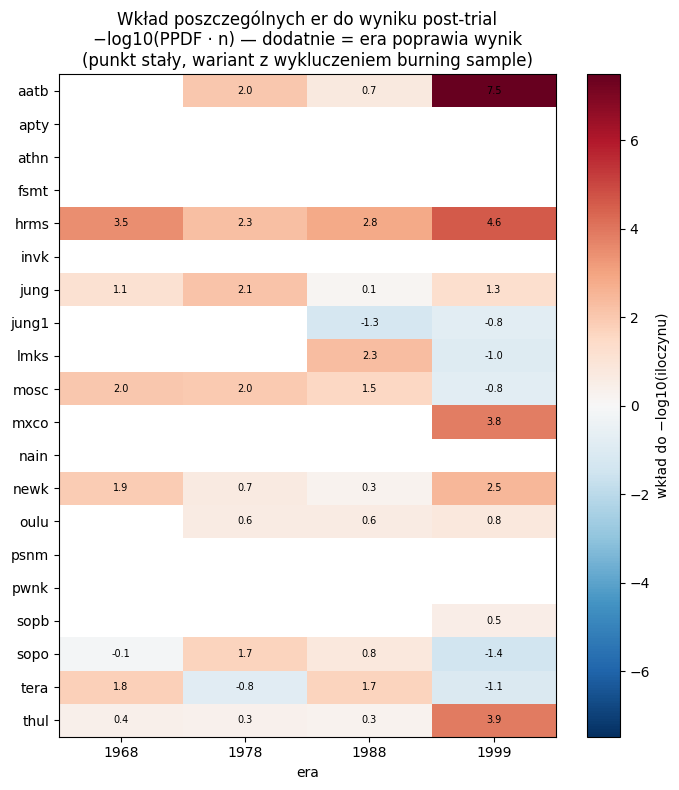

In [6]:
# Wykres 1 (jedno kodowanie: kolor = wklad ery): mapa stacja x era z
# wartoscia -log10(czynnik). Skala rozbiezna wysrodkowana na zerze, bo zero
# to granica "era pomaga / era szkodzi". Metoda ze stalym punktem, wariant
# (a) - czyli dokladnie ten lancuch, z ktorego pochodzi naglowek 31.08.
import matplotlib.pyplot as plt

sub = per_era[(per_era["metoda"] == "stala") & (per_era["wariant"] == "a_z_wykluczeniem")]
mapa = sub.pivot_table(index="station", columns="era", values="wklad_neglog10")
mapa = mapa.reindex(index=STATIONS, columns=ERY_ARTYKULU)

vmax = np.nanmax(np.abs(mapa.to_numpy())) if np.isfinite(mapa.to_numpy()).any() else 1.0

fig, ax = plt.subplots(figsize=(7, 8))
im = ax.imshow(np.ma.masked_invalid(mapa.to_numpy()), cmap="RdBu_r",
               vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(ERY_ARTYKULU)))
ax.set_xticklabels(ERY_ARTYKULU)
ax.set_yticks(range(len(STATIONS)))
ax.set_yticklabels(STATIONS)
ax.set_xlabel("era")
ax.set_title("Wkład poszczególnych er do wyniku post-trial\n"
             "−log10(PPDF · n) — dodatnie = era poprawia wynik\n"
             "(punkt stały, wariant z wykluczeniem burning sample)")
fig.colorbar(im, ax=ax, label="wkład do −log10(iloczynu)")
for i, st in enumerate(STATIONS):
    for j, era in enumerate(ERY_ARTYKULU):
        v = mapa.loc[st, era] if st in mapa.index else np.nan
        if np.isfinite(v):
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/section4_chain_per_era_heatmap.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/section4_chain_per_era_heatmap.png")


Zapisano ../results/section4_chain_total_per_station.png


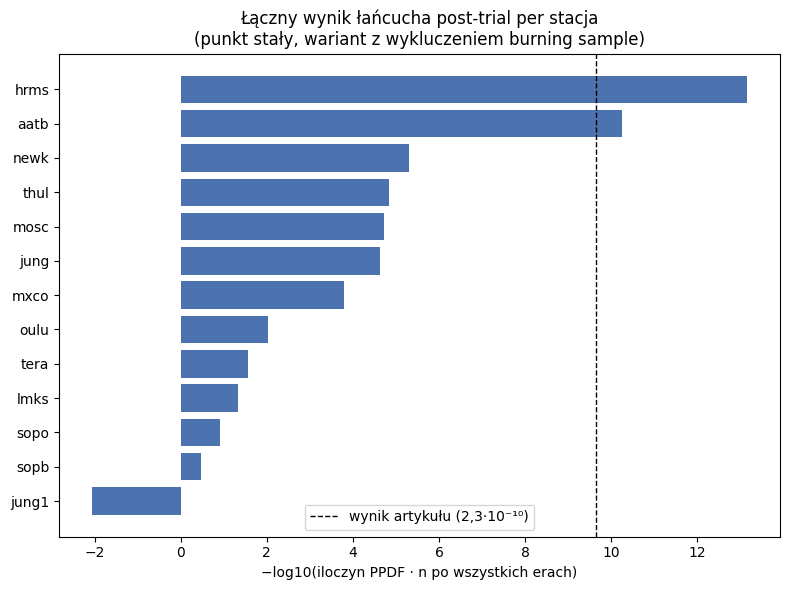

In [7]:
# Wykres 2 (jedno kodowanie: dlugosc slupka): laczny wynik lancucha per
# stacja w tej samej skali co wykres 1, czyli -log10(iloczyn). Linia
# odniesienia: wynik artykulu (iloczyn 2.3e-10 -> -log10 = 9.64).
ARTYKUL_ILOCZYN = 2.3e-10

tot = (podsumowanie[(podsumowanie["metoda"] == "stala")
                    & (podsumowanie["wariant"] == "a_z_wykluczeniem")]
       .dropna(subset=["product"]).copy())
tot["neglog10_iloczyn"] = -np.log10(tot["product"])
tot = tot.sort_values("neglog10_iloczyn")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(tot["station"], tot["neglog10_iloczyn"], color="#4C72B0")
ax.axvline(-np.log10(ARTYKUL_ILOCZYN), color="black", ls="--", lw=1,
           label="wynik artykułu (2,3·10⁻¹⁰)")
ax.set_xlabel("−log10(iloczyn PPDF · n po wszystkich erach)")
ax.set_title("Łączny wynik łańcucha post-trial per stacja\n"
             "(punkt stały, wariant z wykluczeniem burning sample)")
ax.legend()
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/section4_chain_total_per_station.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/section4_chain_total_per_station.png")


In [8]:
# Podsumowanie: czy wynik danej stacji stoi na jednej erze, czy na kilku.
# Miara: udzial najwiekszego DODATNIEGO wkladu w sumie wkladow dodatnich.
# 1.00 = caly wynik pochodzi z jednego minimum (kruche), ~0.25 przy czterech
# erach = rownomiernie rozlozony (mocniejsze).
print("=" * 70)
print("ROZBICIE LANCUCHA POST-TRIAL NA ERY - PODSUMOWANIE")
print("=" * 70)
for metoda, wariant in [("stala", "a_z_wykluczeniem"), ("wolna", "a_z_wykluczeniem")]:
    print()
    print(f"metoda={metoda}, wariant={wariant}")
    s = per_era[(per_era["metoda"] == metoda) & (per_era["wariant"] == wariant)
                & (per_era["status"] == "uzyty")]
    for st in STATIONS:
        w = s[s["station"] == st]
        if not len(w):
            continue
        dod = w[w["wklad_neglog10"] > 0]
        if not len(dod):
            print(f"  {st:6s} brak ery o dodatnim wkladzie")
            continue
        naj = dod.loc[dod["wklad_neglog10"].idxmax()]
        udzial = naj["wklad_neglog10"] / dod["wklad_neglog10"].sum()
        print(f"  {st:6s} er uzytych: {len(w)}, dodatnich: {len(dod)}, "
              f"dominujaca: {int(naj['era'])} (udzial {udzial:.2f}), "
              f"suma -log10 = {w['wklad_neglog10'].sum():.2f}")
print()
print("Do dziennika: dla kazdej stacji, ktora 31.08 przekroczyla 6.3 sigma,")
print("sprawdzic udzial dominujacej ery. Udzial bliski 1.0 oznacza, ze wynik")
print("stoi na jednym punkcie i jest tak mocny jak ten jeden punkt - co przy")
print("znanej niejednorodnosci katalogu USGS (31.08, Watek 1) jest istotnym")
print("zastrzezeniem, a nie formalnoscia.")


ROZBICIE LANCUCHA POST-TRIAL NA ERY - PODSUMOWANIE

metoda=stala, wariant=a_z_wykluczeniem
  aatb   er uzytych: 3, dodatnich: 3, dominujaca: 1999 (udzial 0.73), suma -log10 = 10.25
  hrms   er uzytych: 4, dodatnich: 4, dominujaca: 1999 (udzial 0.35), suma -log10 = 13.16
  jung   er uzytych: 4, dodatnich: 4, dominujaca: 1978 (udzial 0.46), suma -log10 = 4.62
  jung1  brak ery o dodatnim wkladzie
  lmks   er uzytych: 2, dodatnich: 1, dominujaca: 1988 (udzial 1.00), suma -log10 = 1.34
  mosc   er uzytych: 4, dodatnich: 3, dominujaca: 1968 (udzial 0.36), suma -log10 = 4.71
  mxco   er uzytych: 1, dodatnich: 1, dominujaca: 1999 (udzial 1.00), suma -log10 = 3.80
  newk   er uzytych: 4, dodatnich: 4, dominujaca: 1999 (udzial 0.46), suma -log10 = 5.29
  oulu   er uzytych: 3, dodatnich: 3, dominujaca: 1999 (udzial 0.39), suma -log10 = 2.02
  sopb   er uzytych: 1, dodatnich: 1, dominujaca: 1999 (udzial 1.00), suma -log10 = 0.48
  sopo   er uzytych: 4, dodatnich: 2, dominujaca: 1978 (udzial 0.68)